# Sales Prediction Using Python

## Oasis Infobyte Data Science Internship

### Task 5

### Objective

Build a machine learning regression model to predict product sales based on advertising expenditure on TV, Radio, and Newspaper.

### Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-Learn
- Jupyter Notebook

## Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

## Load Dataset

In [2]:
df = pd.read_csv("Advertising.csv")

df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


## Dataset Information

In [3]:
df.shape

(200, 5)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [5]:
df.describe()

,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


In [6]:
df.isnull().sum()

Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

## Exploratory Data Analysis

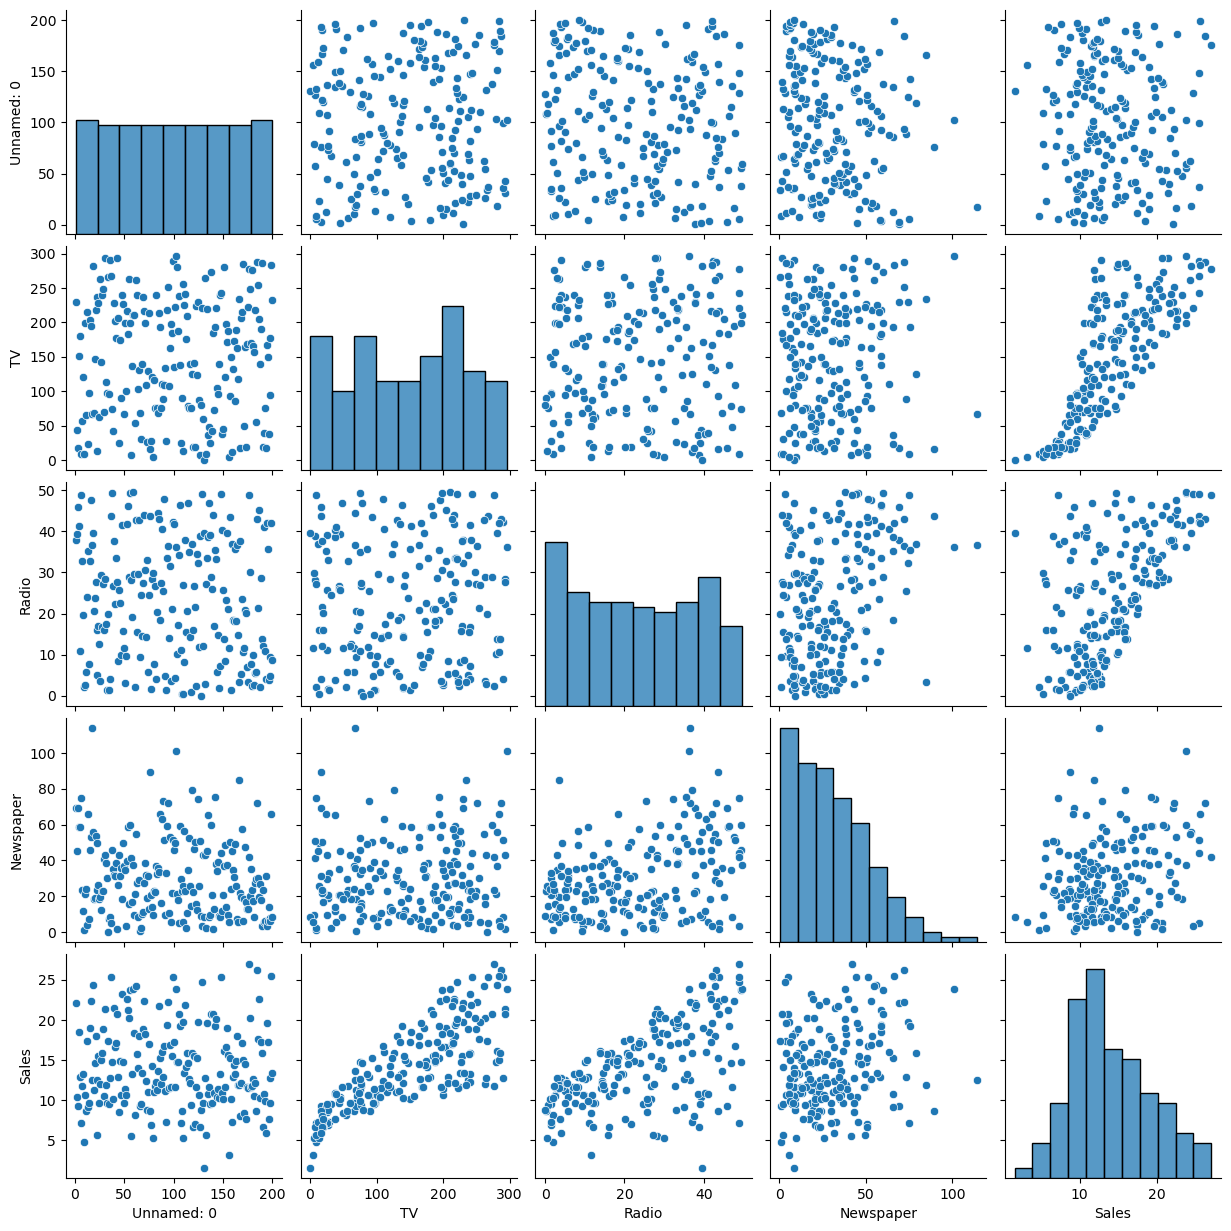

In [8]:
# Pairplot
sns.pairplot(df)

plt.show()

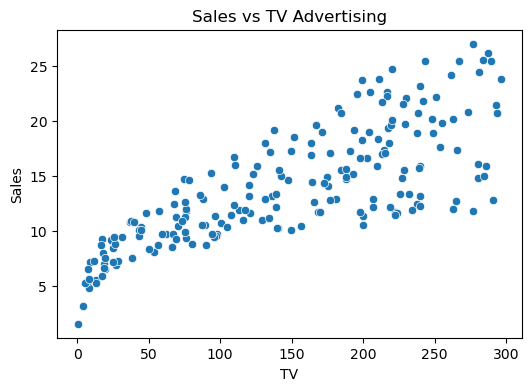

In [9]:
# Sales vs TV
plt.figure(figsize=(6,4))

sns.scatterplot(
    x="TV",
    y="Sales",
    data=df
)

plt.title("Sales vs TV Advertising")

plt.show()

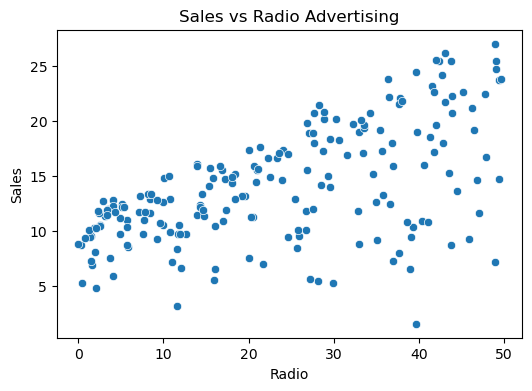

In [10]:
# Sales vs Radio
plt.figure(figsize=(6,4))

sns.scatterplot(
    x="Radio",
    y="Sales",
    data=df
)

plt.title("Sales vs Radio Advertising")

plt.show()

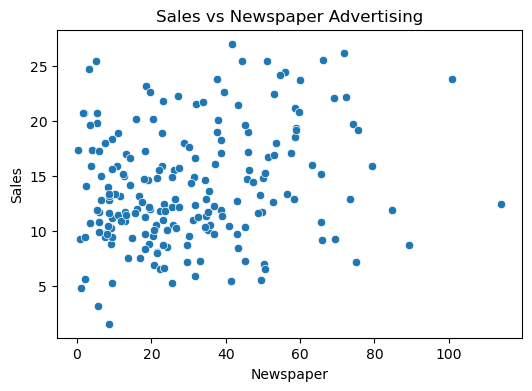

In [11]:
# Sales vs Newspaper
plt.figure(figsize=(6,4))

sns.scatterplot(
    x="Newspaper",
    y="Sales",
    data=df
)

plt.title("Sales vs Newspaper Advertising")

plt.show()

## Correlation Heatmap

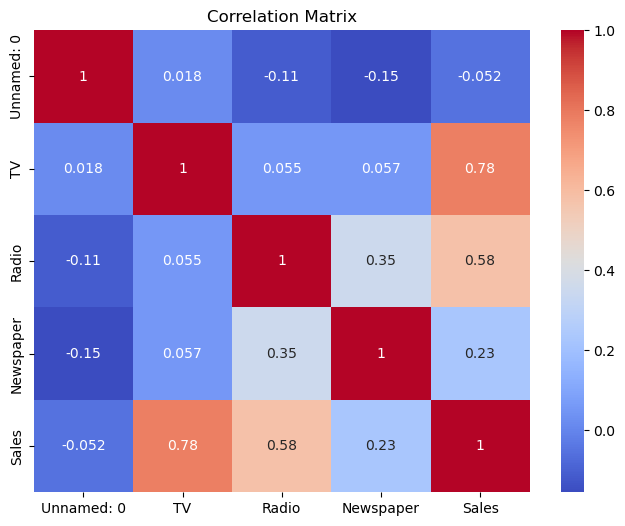

In [12]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

## Train-Test Split

In [13]:
X = df.drop("Sales", axis=1)

y = df["Sales"]

In [14]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Model 1

## Linear Regression

In [15]:
lr = LinearRegression()

lr.fit(X_train,y_train)

pred_lr = lr.predict(X_test)

## Model 2

## Random Forest Regressor

In [16]:
rf = RandomForestRegressor(random_state=42)

rf.fit(X_train,y_train)

pred_rf = rf.predict(X_test)

## Evaluation

In [ ]:
# Helper function

In [17]:
def evaluate(actual,pred):

    mae = mean_absolute_error(actual,pred)

    rmse = np.sqrt(mean_squared_error(actual,pred))

    r2 = r2_score(actual,pred)

    print("MAE :",round(mae,3))

    print("RMSE :",round(rmse,3))

    print("R² Score :",round(r2,3))

In [ ]:
# Evaluate both models

In [18]:
print("Linear Regression")

evaluate(y_test,pred_lr)

Linear Regression
MAE : 1.465
RMSE : 1.789
R² Score : 0.899


In [19]:
print("Random Forest")

evaluate(y_test,pred_rf)

Random Forest
MAE : 0.67
RMSE : 0.823
R² Score : 0.979


## Residual Plot

## Use the better-performing model (suppose Random Forest performs better):

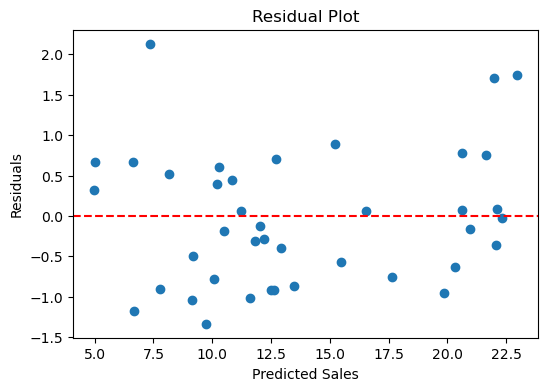

In [20]:
residuals = y_test - pred_rf

plt.figure(figsize=(6,4))

plt.scatter(pred_rf,residuals)

plt.axhline(y=0,color="red",linestyle="--")

plt.xlabel("Predicted Sales")

plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

### Residual Plot Interpretation

The residuals are randomly scattered around zero, indicating that the model does not show any systematic error and provides a good fit to the data.

## Feature Importance

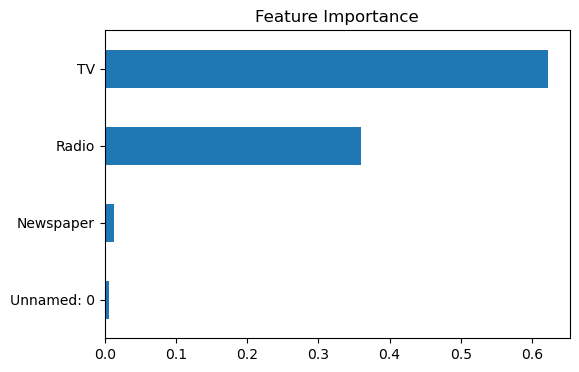

In [21]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(
    kind="barh",
    figsize=(6,4)
)

plt.title("Feature Importance")

plt.show()

## Interpretation

Based on the feature importance (or Linear Regression coefficients), TV advertising has the highest impact on product sales, followed by Radio, while Newspaper has the least influence.

## Conclusion

- Loaded and explored the advertising dataset.
- Performed exploratory data analysis (EDA).
- Visualized relationships between advertising channels and sales.
- Built two regression models:
  - Linear Regression
  - Random Forest Regressor
- Compared model performance using:
  - MAE
  - RMSE
  - R² Score
- Generated a residual plot to evaluate prediction errors.
- Interpreted feature importance to identify the advertising channel with the greatest influence on sales.